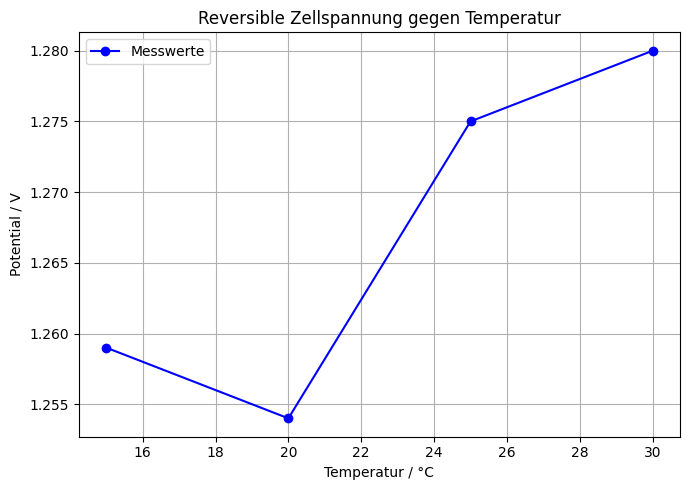

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="S,T", skiprows=38, nrows=4)
df.columns = ["T", "Potential"]  # Großes P!

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Punkte zeichnen
plt.plot(df["T"], df["Potential"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Achsen und Titel
plt.xlabel("Temperatur / °C")
plt.ylabel("Potential / V")
plt.title("Reversible Zellspannung gegen Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

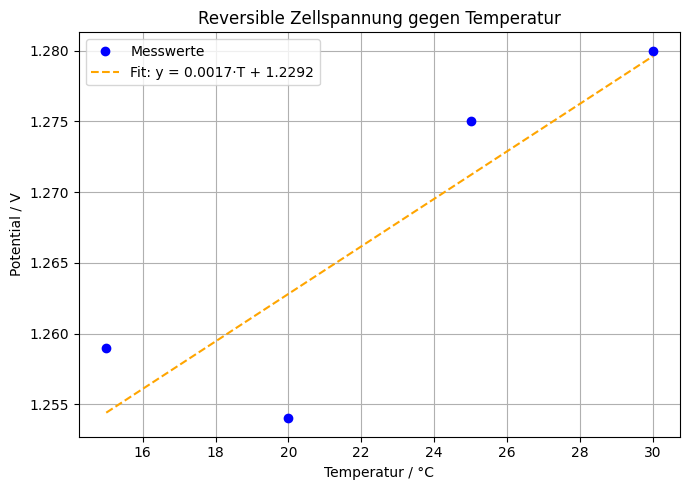

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="S,T", skiprows=38, nrows=4)
df.columns = ["T", "Potential"]

# ===============================
# Lineare Regression (Geradenfit)
# ===============================
x = df["T"]
y = df["Potential"]
coeffs = np.polyfit(x, y, deg=1)        # Grad 1 = Gerade
poly = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = poly(x_fit)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Messpunkte
plt.plot(x, y, 'o', color='blue', label='Messwerte')

# Fit-Gerade
plt.plot(x_fit, y_fit, '--', color='orange',
         label=f'Fit: y = {coeffs[0]:.4f}·T + {coeffs[1]:.4f}')

# Achsen und Titel
plt.xlabel("Temperatur / °C")
plt.ylabel("Potential / V")
plt.title("Reversible Zellspannung gegen Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

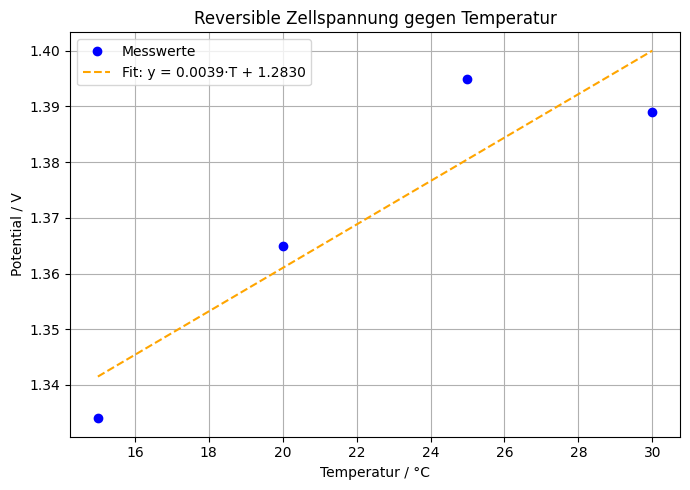

Steigung dE/dT       : 0.003900 ± 0.001270 V/K
ΔS (Reaktionsentropie): 752.58 ± 245.16 J/mol·K


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="S,T", skiprows=38, nrows=4)
df.columns = ["T", "Potential"]

# ===============================
# Lineare Regression (Geradenfit)
# ===============================
x = df["T"]
y = df["Potential"]

# Fit mit Unsicherheiten
def lin_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(lin_func, x, y)
slope, intercept = popt
slope_err = sqrt(pcov[0, 0])  # Fehler der Steigung

# Fit-Kurve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = lin_func(x_fit, *popt)

# ===============================
# Entropie berechnen
# ===============================
F = 96485  # C/mol
z = 2      # Anzahl der übertragenen Elektronen (z.B. 2 für Elektrolyse von Wasser)

delta_S = slope * z * F
delta_S_err = slope_err * z * F

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label='Messwerte')
plt.plot(x_fit, y_fit, '--', color='orange',
         label=f'Fit: y = {slope:.4f}·T + {intercept:.4f}')

plt.xlabel("Temperatur / °C")
plt.ylabel("Potential / V")
plt.title("Reversible Zellspannung gegen Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnis ausgeben
# ===============================
print(f"Steigung dE/dT       : {slope:.6f} ± {slope_err:.6f} V/K")
print(f"ΔS (Reaktionsentropie): {delta_S:.2f} ± {delta_S_err:.2f} J/mol·K")

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="S,U", skiprows=81, nrows=6)
df.columns = ["T", "Reversible Zellspannung"]

# ===============================
# Lineare Regression (Geradenfit)
# ===============================
x = df["T"]
y = df["Reversible Zellspannung"]

# Fit mit Unsicherheiten
def lin_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(lin_func, x, y)
slope, intercept = popt
slope_err = sqrt(pcov[0, 0])  # Fehler der Steigung

# Fit-Kurve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = lin_func(x_fit, *popt)

# ===============================
# Entropie berechnen
# ===============================
F = 96485  # C/mol
z = 2      # Anzahl der übertragenen Elektronen (z.B. 2 für Elektrolyse von Wasser)

delta_S = slope * z * F
delta_S_err = slope_err * z * F

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label='Messwerte')
plt.plot(x_fit, y_fit, '--', color='orange',
         label=f'Fit: y = {slope:.4f}·T + {intercept:.4f}')

plt.xlabel("Temperatur / °C")
plt.ylabel("Reversible Zellspannung / V")
plt.title("Reversible Zellspannung gegen Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnis ausgeben
# ===============================
print(f"Steigung dE/dT       : {slope:.6f} ± {slope_err:.6f} V/K")
print(f"ΔS (Reaktionsentropie): {delta_S:.2f} ± {delta_S_err:.2f} J/mol·K")

ValueError: array must not contain infs or NaNs

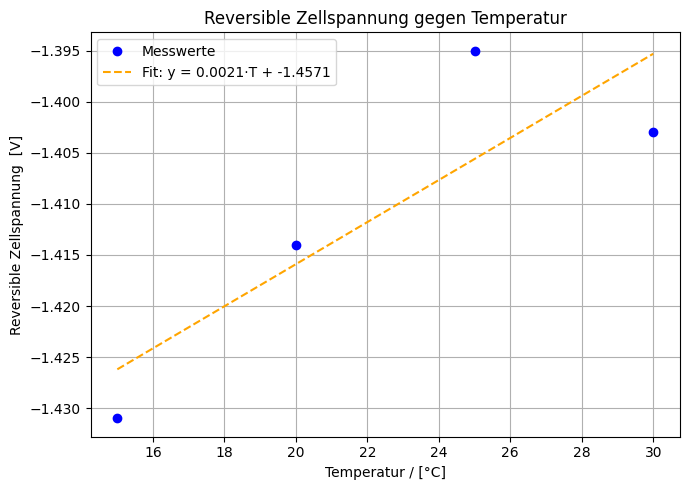

Steigung dE/dT       : 0.002060 ± 0.000891 V/K
ΔS (Reaktionsentropie): 397.52 ± 171.86 J/mol·K


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="S,U", skiprows=81, nrows=6)
df.columns = ["T", "Reversible Zellspannung"]

# Konvertieren & Bereinigen
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

# ===============================
# Lineare Regression (Geradenfit)
# ===============================
x = df["T"].values
y = df["Reversible Zellspannung"].values

def lin_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(lin_func, x, y)
slope, intercept = popt
slope_err = sqrt(pcov[0, 0])

# Fit-Kurve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = lin_func(x_fit, *popt)

# ===============================
# Entropie berechnen
# ===============================
F = 96485
z = 2

delta_S = slope * z * F
delta_S_err = slope_err * z * F

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label='Messwerte')
plt.plot(x_fit, y_fit, '--', color='orange',
         label=f'Fit: y = {slope:.4f}·T + {intercept:.4f}')
plt.xlabel("Temperatur / [°C]")
plt.ylabel("Reversible Zellspannung  [V]")
plt.title("Reversible Zellspannung gegen Temperatur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnis
# ===============================
print(f"Steigung dE/dT       : {slope:.6f} ± {slope_err:.6f} V/K")
print(f"ΔS (Reaktionsentropie): {delta_S:.2f} ± {delta_S_err:.2f} J/mol·K")